In [2]:
import matplotlib.pyplot as plt
import sys, pathlib
import time
sys.path.insert(0, str(pathlib.Path("..").resolve()))

In [28]:
import statistics
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

def _compute_stats(results):
    ns = sorted(results)
    means = [statistics.mean(results[n]) for n in ns]
    stds  = [statistics.stdev(results[n]) for n in ns]
    return np.array(ns, dtype=float), np.array(means), np.array(stds)

def plot_runtime(results, title="generate() runtime"):
    ns_arr, means_arr, stds_arr = _compute_stats(results)
    fig, ax = plt.subplots()
    ax.errorbar(ns_arr, means_arr, yerr=stds_arr, marker="o", capsize=5, label="mean ± std")
    ax.set_xlabel("board size n")
    ax.set_ylabel("time (ms)")
    ax.set_title(title)
    ax.legend()
    plt.show()

def plot_growth(results, title=""):
    ns_arr, means_arr, stds_arr = _compute_stats(results)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.set_xscale("log"); ax1.set_yscale("log")
    ax1.errorbar(ns_arr, means_arr, yerr=stds_arr, marker="o", capsize=5)
    ax1.set_title(f"log-log (straight = polynomial) {title}")
    ax1.set_xlabel("n"); ax1.set_ylabel("ms")

    ax2.set_yscale("log")
    ax2.errorbar(ns_arr, means_arr, yerr=stds_arr, marker="o", capsize=5)
    ax2.set_title(f"log-linear (straight = exponential) {title}")
    ax2.set_xlabel("n")

    plt.tight_layout()
    plt.show()

def fit_growth(results):
    ns_arr, means_arr, _ = _compute_stats(results)
    log_ns    = np.log(ns_arr)
    log_means = np.log(means_arr)

    r_poly = stats.pearsonr(log_ns, log_means).statistic ** 2
    r_exp  = stats.pearsonr(ns_arr, log_means).statistic ** 2

    slope, _ = np.polyfit(ns_arr, log_means, 1)
    verdict = "exponential" if r_exp > r_poly else "polynomial"

    print(f"R² log-log (polynomial):     {r_poly:.4f}")
    print(f"R² log-linear (exponential): {r_exp:.4f}")
    print(f"verdict: {verdict}, ~{np.exp(slope):.2f}x per +1 n")


# Runtimes
What is the big O of our algorithms?

In [30]:
# Gen Single
from gensingle import generate

RUNS = 10  # boards per size
sizes = range(5, 14)

results_single = {}  # n -> list of ms times

for n in sizes:
    times = []
    for _ in range(RUNS):
        t0 = time.perf_counter()
        generate(n)
        times.append((time.perf_counter() - t0) * 1000)
    results_single[n] = times
    print(f"n={n}: median={sorted(times)[len(times)//2]:.1f} ms")
print("Done!")

n=5: median=0.6 ms
n=6: median=1.3 ms
n=7: median=6.9 ms
n=8: median=11.5 ms
n=9: median=13.9 ms
n=10: median=13.5 ms
n=11: median=91.3 ms
n=12: median=196.9 ms
n=13: median=924.2 ms
Done!


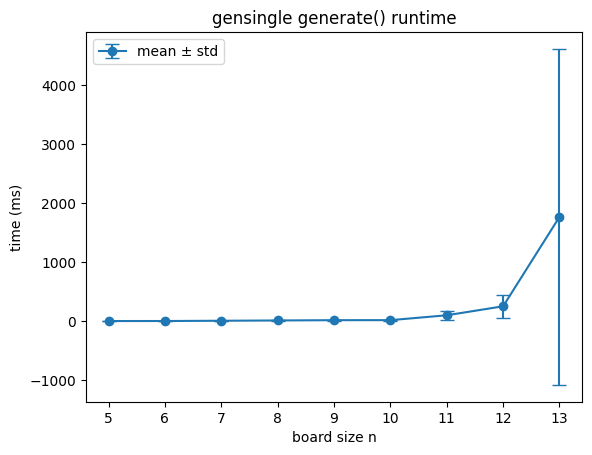

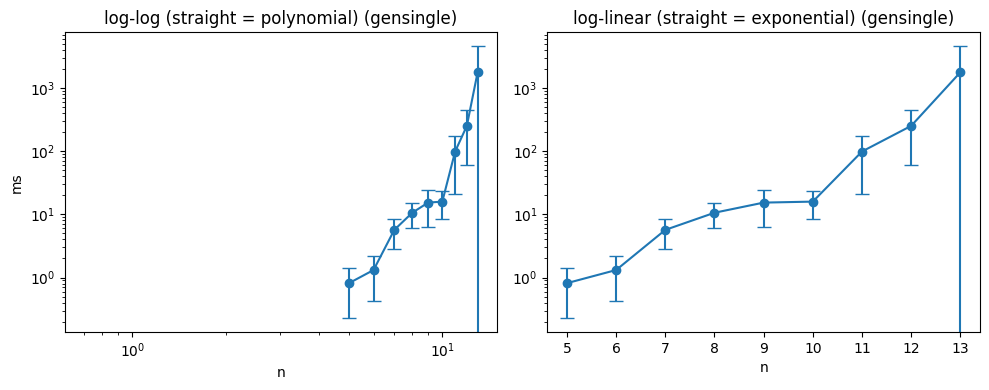

R² log-log (polynomial):     0.8982
R² log-linear (exponential): 0.9452
verdict: exponential, ~2.40x per +1 n


In [31]:
plot_runtime(results_single, "gensingle generate() runtime")
plot_growth(results_single, "(gensingle)")
fit_growth(results_single)

In [29]:
# Gen Double
from gendouble import generate

RUNS = 10  # boards per size
sizes = range(8, 13)

results_double = {}  # n -> list of ms times

for n in sizes:
    times = []
    for _ in range(RUNS):
        t0 = time.perf_counter()
        generate(n)
        times.append((time.perf_counter() - t0) * 1000)
    results_double[n] = times
    print(f"n={n}: median={sorted(times)[len(times)//2]:.1f} ms")
print("Done!")

n=8: median=352.6 ms
n=9: median=80.2 ms
n=10: median=84.3 ms
n=11: median=272.5 ms
n=12: median=1808.8 ms
Done!


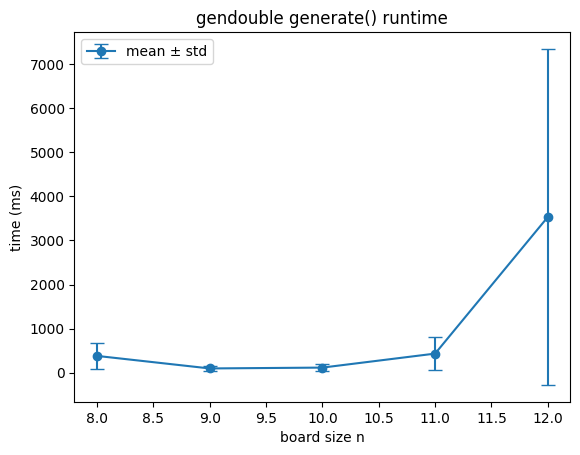

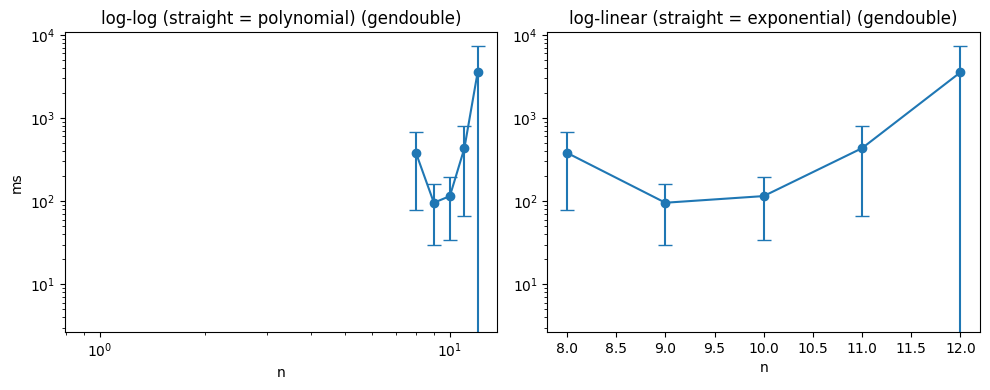

R² log-log (polynomial):     0.3698
R² log-linear (exponential): 0.4283
verdict: exponential, ~1.82x per +1 n


In [32]:
plot_runtime(results_double, "gendouble generate() runtime")
plot_growth(results_double, "(gendouble)")
fit_growth(results_double)
